`conda activate r_python`

In [1]:
library(tidyverse)
library(Seurat)
library(stringr)
library(tibble)
library(data.table)
library(Matrix)
library(dplyr)
library(future)
library(HGNChelper)
library(BiocParallel)
library(scDblFinder)
library(DoubletFinder)
library(KernSmooth)
library(cluster)
library(parallel)
library(dittoSeq)
library(scCustomize)
library(patchwork)
source("scripts/helper_functions_v1.R")
set.seed(1)
plan("multiprocess", workers = 24)
options(future.globals.maxSize = 1000 * 1024^6)

── Attaching core tidyverse packages ───────── tidyverse 2.0.0 ──
✔ dplyr     1.1.0     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.1     ✔ tibble    3.1.8
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ─────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Attaching SeuratObject


Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose



Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: SingleCe

### DeSisto2023

##### Read CellBender corrected matrices

In [2]:
path.dir <- paste0('/hpc/pmc_stunnenberg/cruiz/scRNA/cellranger-output/pmc_patients',
                     '/dipg_primary_tumors/deep_sequencing/cellbender_filtered_matrices/DeSisto2023/')

In [3]:
files <- list.files(path = path.dir, recursive = FALSE)
files

[1] "DMG_1.output_filtered.h5" "DMG_2.output_filtered.h5"
[3] "DMG_3.output_filtered.h5" "DMG_4.output_filtered.h5"
[5] "DMG_5.output_filtered.h5"

In [4]:
sampleID <- str_sub(files, end=str_locate(files,"output")[,1]-2)
sampleID

[1] "DMG_1" "DMG_2" "DMG_3" "DMG_4" "DMG_5"

In [5]:
corrected <- list()
for (i in 1:length(files)) {
    seu_obj.data <- Read_CellBender_h5_Mat(file_name = paste0(path.dir,
                                                 files[[i]]))
    
    seu_obj <- CreateSeuratObject(seu_obj.data, min.features = 0, min.cells = 0,
                                  project = sampleID[i])
    seu_obj<- RenameCells(object = seu_obj, add.cell.id = sampleID[i])
    
    corrected <- append(corrected, seu_obj)
}
head(corrected, n = 3)

[[1]]
An object of class Seurat 
36601 features across 2868 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)

[[2]]
An object of class Seurat 
36601 features across 2452 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)

[[3]]
An object of class Seurat 
36601 features across 4142 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)


In [7]:
cat(sum(unlist(lapply(corrected, ncol))),"cells (total) loaded...\n")

19640 cells (total) loaded...


In [9]:
DeSisto2023 <- merge(corrected[[1]], y = unlist(corrected[2:length(corrected)]), 
                  project = "DeSisto2023", merge.data = FALSE)
DeSisto2023
str(DeSisto2023)

An object of class Seurat 
36601 features across 19640 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay' [package "SeuratObject"] with 8 slots
  .. .. .. ..@ counts       :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. ..@ i       : int [1:29849333] 6 14 16 24 29 30 36 37 44 45 ...
  .. .. .. .. .. ..@ p       : int [1:19641] 0 11387 22887 32491 40796 48917 57056 64753 72885 81764 ...
  .. .. .. .. .. ..@ Dim     : int [1:2] 36601 19640
  .. .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. .. ..$ : chr [1:36601] "MIR1302-2HG" "FAM138A" "OR4F5" "AL627309.1" ...
  .. .. .. .. .. .. ..$ : chr [1:19640] "DMG_1_ATTCATCCACCGCTGA-1" "DMG_1_TTTACCAAGCACGGAT-1" "DMG_1_CCTCCAAAGGCATCAG-1" "DMG_1_TTCAGGAAGGTCGTGA-1" ...
  .. .. .. .. .. ..@ x       : num [1:29849333] 1 2 1 3 4 1 2 1 8 1 ...
  .. .. .. .. .. ..@ factors : list()
  .. .. .. ..@ data         :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. ..@ i       : int [

In [10]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,10724036,572.8,19952522,1065.6,13703763,731.9
Vcells,153250181,1169.3,257802267,1966.9,229823521,1753.5


In [11]:
low_quality <- subset(DeSisto2023, subset = nFeature_RNA <= 200)
high_quality <- subset(DeSisto2023, subset = nFeature_RNA > 200)
low_quality
high_quality

An object of class Seurat 
36601 features across 9984 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)

An object of class Seurat 
36601 features across 9656 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)

##### Identifying doublets with DoubletFinder

In [12]:
high_quality <- SplitObject(high_quality, 'orig.ident')
high_quality

$DMG_1
An object of class Seurat 
36601 features across 501 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)

$DMG_2
An object of class Seurat 
36601 features across 1995 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)

$DMG_3
An object of class Seurat 
36601 features across 1520 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)

$DMG_4
An object of class Seurat 
36601 features across 1556 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)

$DMG_5
An object of class Seurat 
36601 features across 4084 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)


In [13]:
high_quality <- lapply(high_quality, seuPreProcess)

Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pca_RNA_ to pcaRNA_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to pcaRNA_”
Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pca_RNA_ to pcaRNA_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to pcaRNA_”
Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an u

 ############################################
 ### DoubletFinder for dataset number  1 ###
 ############################################


Loading required package: ROCR

Loading required package: fields

Loading required package: spam

Spam version 2.9-1 (2022-08-07) is loaded.
Type 'help( Spam)' or 'demo( spam)' for a short introduction 
and overview of this package.
Help for individual functions is also obtained by adding the
suffix '.spam' to the function name, e.g. 'help( chol.spam)'.


Attaching package: ‘spam’


The following object is masked from ‘package:stats4’:

    mle


The following object is masked from ‘package:Matrix’:

    det


The following objects are masked from ‘package:base’:

    backsolve, forwardsolve


Loading required package: viridis

Loading required package: viridisLite


Try help(fields) to get started.



NULL
 ############################################
 ### DoubletFinder for dataset number  2 ###
 ############################################


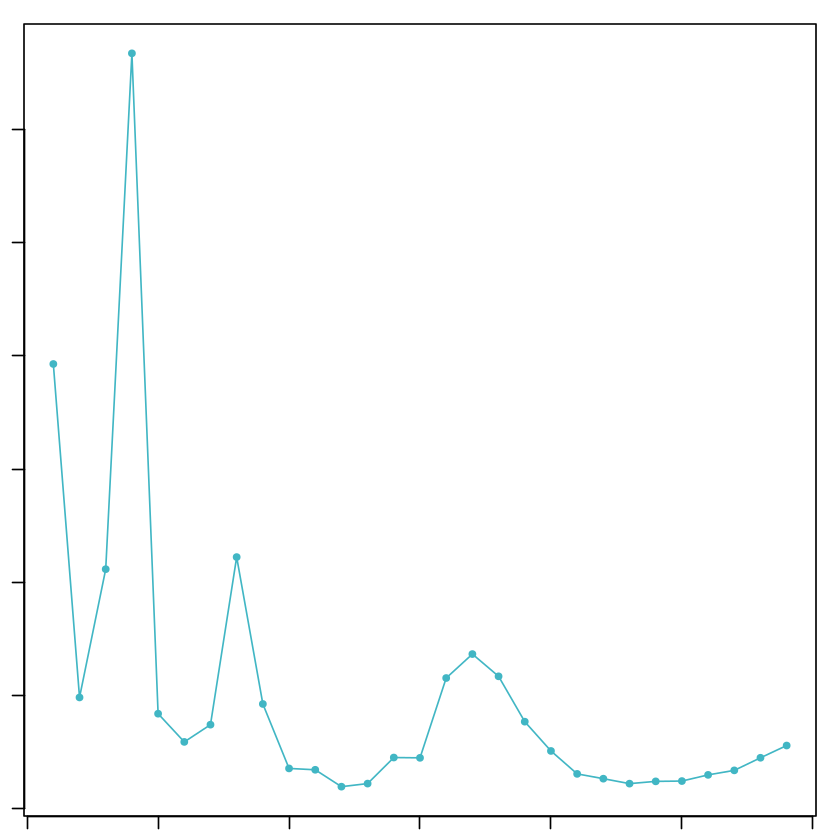

NULL
 ############################################
 ### DoubletFinder for dataset number  3 ###
 ############################################


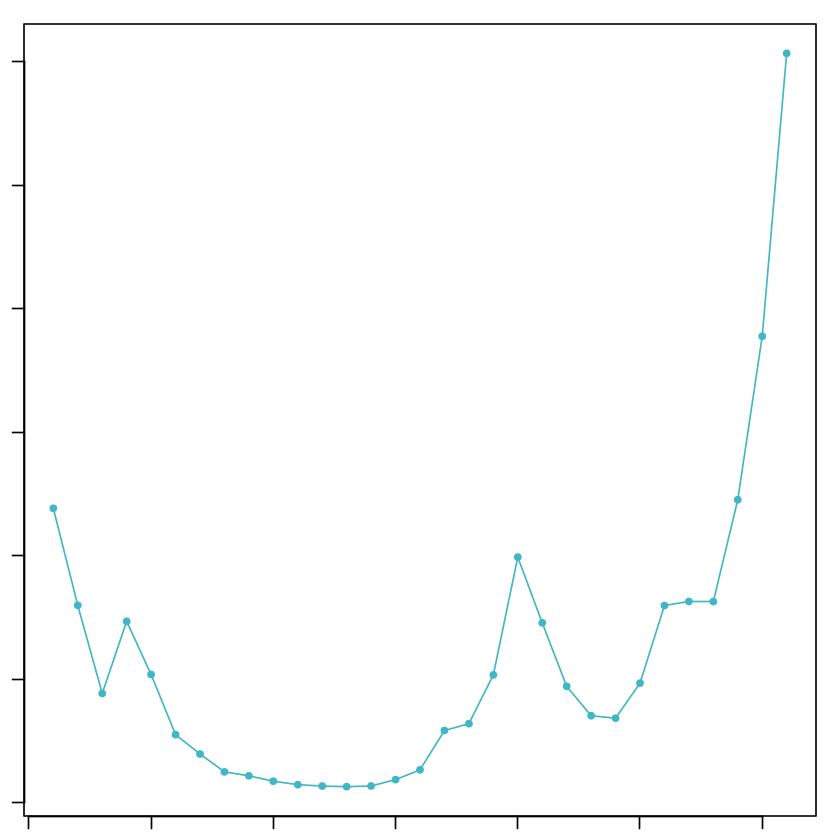

NULL
 ############################################
 ### DoubletFinder for dataset number  4 ###
 ############################################


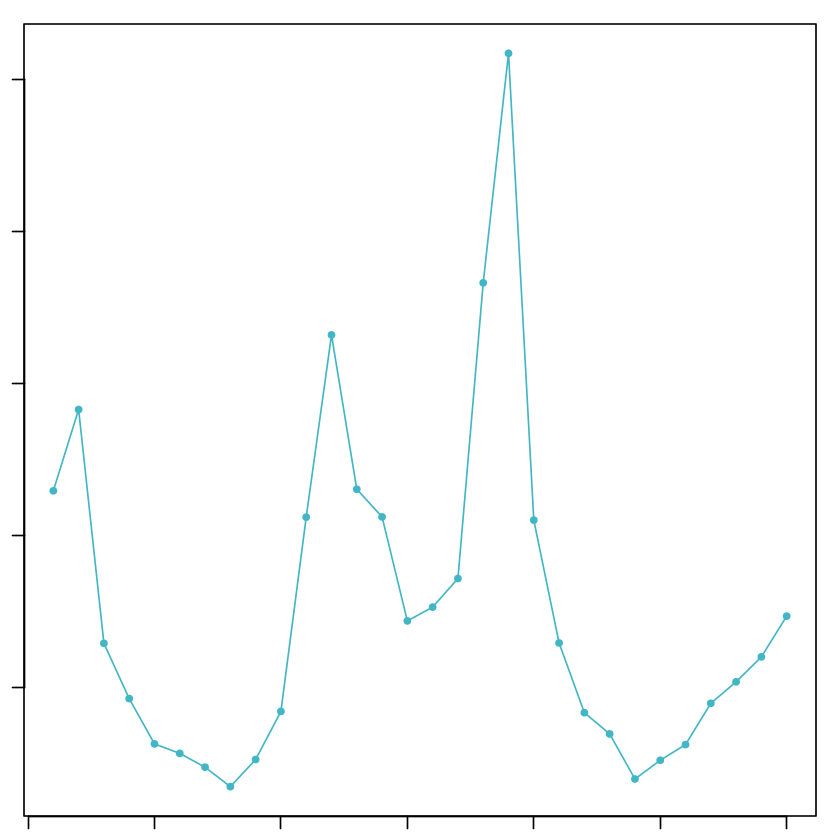

NULL
 ############################################
 ### DoubletFinder for dataset number  5 ###
 ############################################


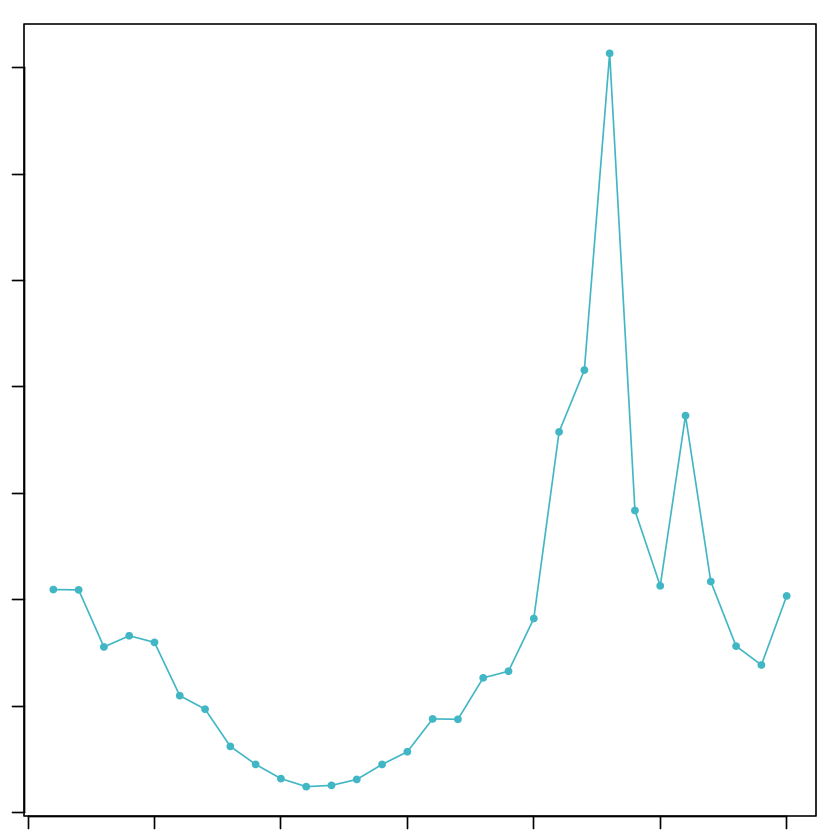

NULL


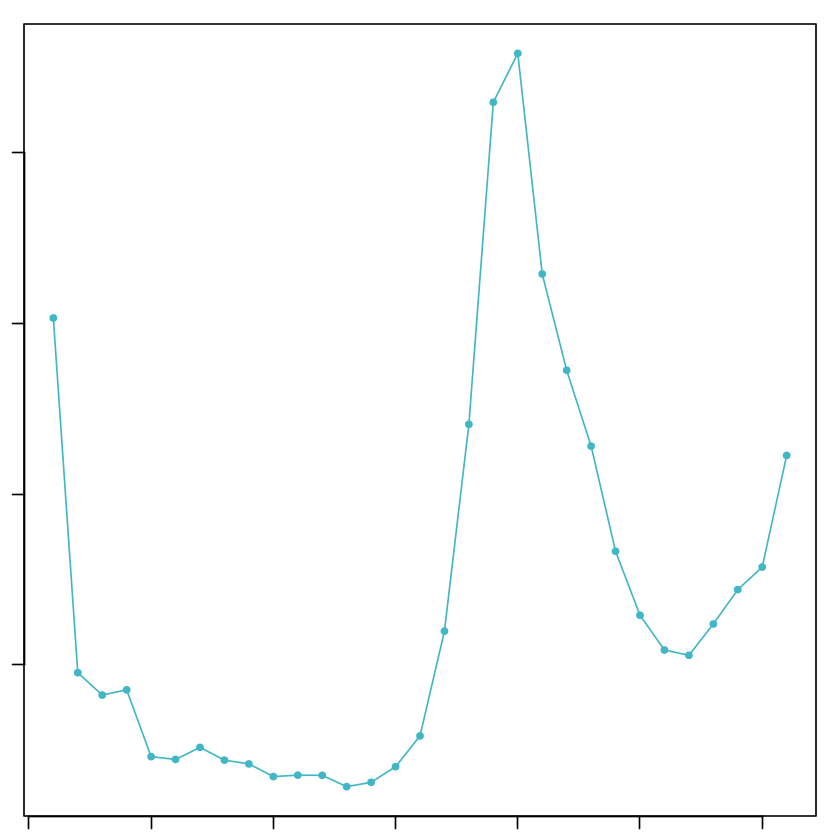

In [14]:
# https://github.com/mckellardw/scMuscle/blob/main/R_scripts/scMuscle_github_v1.R

bcmvn <- list()
pK <- list()
homotypic.prop <- list()
nExp_poi <- list()
nExp_poi.adj <- list()

# Estimated Doublet Rate for each dataset
edr <- estimateDoubletRate.DWM(seur.list = high_quality)/100 #use your own known EDR here

for(i in 1:length(high_quality)){ 
  cat(' ############################################\n',
      '### DoubletFinder for dataset number ', i, '###\n',
      '############################################\n')
  
  ## pK Identification (no ground-truth)
  bcmvn[[i]]<- paramSweep_v3(
    seu=high_quality[[i]],
    PCs = 1:high_quality[[i]]@reductions$umap_RNA@misc$n.pcs.used, 
    num.cores = 24
  ) %>% summarizeSweep(
    GT = FALSE
  ) %>% find.pK() 
  
  # Pull out max of bcmvn
  pK[[i]] <- as.numeric(as.character(bcmvn[[i]]$pK[bcmvn[[i]]$BCmetric==max(bcmvn[[i]]$BCmetric)])) # ugly, but functional...
  
  ## Homotypic Doublet Proportion Estimate
  homotypic.prop[[i]] <- modelHomotypic(high_quality[[i]]$seurat_clusters) 
  
  nExp_poi[[i]] <- round(edr[[i]]*length(colnames(high_quality[[i]])))  
  nExp_poi.adj[[i]] <- round(nExp_poi[[i]]*(1-homotypic.prop[[i]]))
}

In [15]:
# Run DoubletFinder
for(i in 1:length(high_quality)){
  high_quality[[i]] <- 
    doubletFinder_V3.DWM_v2( # just changed it so the output metadata column name is customizable
      seu=high_quality[[i]], 
      PCs = 1:high_quality[[i]]@reductions$umap_RNA@misc$n.pcs.used, 
      pN = 0.25, #default value
      pK= pK[[i]], 
      nExp = nExp_poi.adj[[i]],  
      reuse.pANN = F, 
      classification.name='DF.class', 
      pANN.name='DF.score'
    )
}

Creating  167  artificial doublets from  501  cells...
Creating Seurat object with artificial doublets...
     Piping FindVariableFeatures(), ScaleData(), and RunPCA()...


Centering and scaling data matrix



Calculating PC distance matrix...
Computing pANN...
   nCells =  668  
   k =  33  
Classifying doublets...
Creating  665  artificial doublets from  1995  cells...
Creating Seurat object with artificial doublets...
     Piping FindVariableFeatures(), ScaleData(), and RunPCA()...


Centering and scaling data matrix



Calculating PC distance matrix...
Computing pANN...
   nCells =  2660  
   k =  798  
Classifying doublets...
Creating  507  artificial doublets from  1520  cells...
Creating Seurat object with artificial doublets...
     Piping FindVariableFeatures(), ScaleData(), and RunPCA()...


...

Calculating PC distance matrix...
Computing pANN...
   nCells =  2027  
   k =  385  
Classifying doublets...
Creating  519  artificial doublets from  1556  cells...
Creating Seurat object with artificial doublets...
     Piping FindVariableFeatures(), ScaleData(), and RunPCA()...


Centering and scaling data matrix



Calculating PC distance matrix...
Computing pANN...
   nCells =  2075  
   k =  477  
Classifying doublets...
Creating  1361  artificial doublets from  4084  cells...
Creating Seurat object with artificial doublets...
     Piping FindVariableFeatures(), ScaleData(), and RunPCA()...


Centering and scaling data matrix



Calculating PC distance matrix...
Computing pANN...
   nCells =  5445  
   k =  1035  
Classifying doublets...


### Identifying doublets with scDblFinder

In [16]:
high_quality <- merge(high_quality[[1]], y = unlist(high_quality[2:length(high_quality)]))
bp <- MulticoreParam(12, RNGseed=1234)
high_quality_sce <- scDblFinder(GetAssayData(high_quality, slot="counts"), 
                            samples=high_quality$orig.ident, 
                            BPPARAM=bp)
high_quality$scDblFinder.score <- high_quality_sce$scDblFinder.score
high_quality$scDblFinder.class <- high_quality_sce$scDblFinder.class

Assuming the input to be a matrix of counts or expected counts.



### Merge matrices

In [17]:
low_quality$DF.class <- 'Not assessed'
low_quality$DF.score <- 0
low_quality$scDblFinder.class <- 'Not assessed'
low_quality$scDblFinder.score <- 0

In [18]:
doublet_meta <- rbind(FetchData(high_quality, c('DF.class', 'DF.score',
                                                'scDblFinder.class', 'scDblFinder.score')),
                      FetchData(low_quality, c('DF.class', 'DF.score',
                                                'scDblFinder.class', 'scDblFinder.score'))
                               )
doublet_meta

,DF.class,DF.score,scDblFinder.class,scDblFinder.score
,<chr>,<dbl>,<fct>,<dbl>
DMG_1_ATTCATCCACCGCTGA-1,Singlet,0.36363636,singlet,0.3241701
DMG_1_TTTACCAAGCACGGAT-1,Doublet,0.42424242,singlet,0.2109675
DMG_1_CCTCCAAAGGCATCAG-1,Singlet,0.39393939,singlet,0.2747451
DMG_1_TTCAGGAAGGTCGTGA-1,Singlet,0.18181818,singlet,0.1538074
DMG_1_AAAGTCCAGTTGCCCG-1,Singlet,0.36363636,singlet,0.1479354
DMG_1_CCTCATGTCATGAGAA-1,Singlet,0.12121212,singlet,0.5568926
DMG_1_ATTCTTGTCTATGTGG-1,Singlet,0.33333333,singlet,0.2623233
DMG_1_AGGCCACGTAATCAAG-1,Singlet,0.21212121,singlet,0.2228253
DMG_1_GAAGCCCTCCTTATGT-1,Singlet,0.33333333,singlet,0.6477901


In [19]:
DeSisto2023 <- AddMetaData(DeSisto2023, doublet_meta)
DeSisto2023@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,DF.class,DF.score,scDblFinder.class,scDblFinder.score
,<chr>,<dbl>,<int>,<chr>,<dbl>,<fct>,<dbl>
DMG_1_ATTCATCCACCGCTGA-1,DMG_1,141938,11387,Singlet,0.36363636,singlet,0.3241701
DMG_1_TTTACCAAGCACGGAT-1,DMG_1,123722,11500,Doublet,0.42424242,singlet,0.2109675
DMG_1_CCTCCAAAGGCATCAG-1,DMG_1,77534,9604,Singlet,0.39393939,singlet,0.2747451
DMG_1_TTCAGGAAGGTCGTGA-1,DMG_1,70747,8305,Singlet,0.18181818,singlet,0.1538074
DMG_1_AAAGTCCAGTTGCCCG-1,DMG_1,70226,8121,Singlet,0.36363636,singlet,0.1479354
DMG_1_CCTCATGTCATGAGAA-1,DMG_1,67410,8139,Singlet,0.12121212,singlet,0.5568926
DMG_1_ATTCTTGTCTATGTGG-1,DMG_1,63025,7697,Singlet,0.33333333,singlet,0.2623233
DMG_1_AGGCCACGTAATCAAG-1,DMG_1,60568,8132,Singlet,0.21212121,singlet,0.2228253
DMG_1_GAAGCCCTCCTTATGT-1,DMG_1,59824,8879,Singlet,0.33333333,singlet,0.6477901


In [20]:
# since some patients have different samples: i) 'ID' stores the overall patient ID and ii) 'SampleID' store the different libraries associated with each patient

DeSisto2023$ID <- DeSisto2023$orig.ident
table(DeSisto2023$ID)


DMG_1 DMG_2 DMG_3 DMG_4 DMG_5 
 2868  2452  4142  1831  8347 

In [21]:
DeSisto2023$SampleID <- DeSisto2023$orig.ident
DeSisto2023$Data <- 'RNA_only'
DeSisto2023$orig.ident <- NULL

#### Run dimensional reduction and compare both predictions

In [22]:
# Identification of highly variable features (feature selection)
DeSisto2023 <- DeSisto2023 %>%
            NormalizeData() %>% 
            FindVariableFeatures() %>% 
            ScaleData() %>%
            RunPCA() %>%
            RunUMAP(dims = 1:20)

Centering and scaling data matrix

PC_ 1 
Positive:  CRYAB, GFAP, C1orf61, MT2A, MT1X, H19, TIMP4, ID4, SPARC, BCAS1 
	   PTGDS, ID3, CLU, IGFBP5, VGF, DANCR, GALNT13, DLL3, VIPR2, PLP1 
	   GALNT9, MYT1L, APOD, NNAT, FERMT1, MT1M, ADAMTSL1, SPARCL1, SERPINA3, KCNMB2 
Negative:  SRGN, APBB1IP, DOCK8, TBXAS1, LYN, RBM47, ARHGAP26, PTPRC, FYB1, SAMSN1 
	   DOCK2, CLEC7A, SFMBT2, CSF2RA, PLXDC2, SLC11A1, INPP5D, CYBA, FGD4, MAML3 
	   LAPTM5, SYK, NEAT1, MYO1F, PIK3R5, LNCAROD, CD74, FMN1, ELL2, CD86 
PC_ 2 
Positive:  C1QB, C1QA, C1QC, TYROBP, FCER1G, CD74, HLA-DPA1, AIF1, CYBA, LAPTM5 
	   SPP1, TREM2, VSIG4, C3, HLA-DRA, FCGR3A, CD14, HLA-DRB1, RNASET2, APOC2 
	   ALOX5AP, FCGR1A, NPC2, CSF1R, CTSS, MS4A6A, TMIGD3, ITGB2, HLA-DPB1, CD68 
Negative:  DLGAP1, DSCAM, GALNT13, FMN2, TMEM108, CACNB2, RBFOX1, PARD3B, GABPB1-AS1, KCNMB2 
	   CHRM3, GPC6, AF279873.3, SGCZ, VCAN, TENM4, ROBO2, NRG1, AKAP13, ADCY2 
	   KCNH1, CHIC2, PRICKLE1, RMST, RFX4, PKP4, KHDRBS2, TIMP3, MIR4300HG, PDE1A 
PC

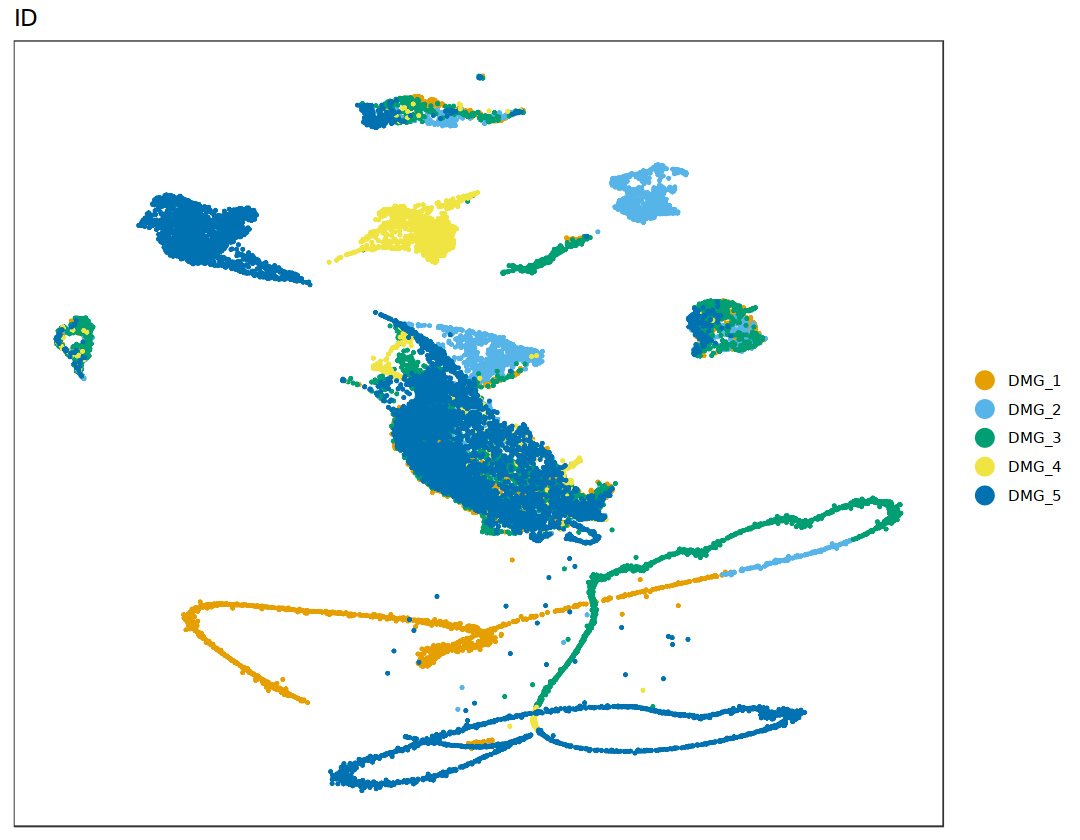

In [23]:
options(repr.plot.height = 7, repr.plot.width = 9)
dittoDimPlot(DeSisto2023,
             reduction.use = "umap", var = "ID", 
             do.label = FALSE,
             do.raster = TRUE) + NoAxes() 

In [24]:
dittoColors()[1:3]

[1] "#E69F00" "#56B4E9" "#009E73"

Warning message in as_grob.default(plot):
“Cannot convert object of class character into a grob.”


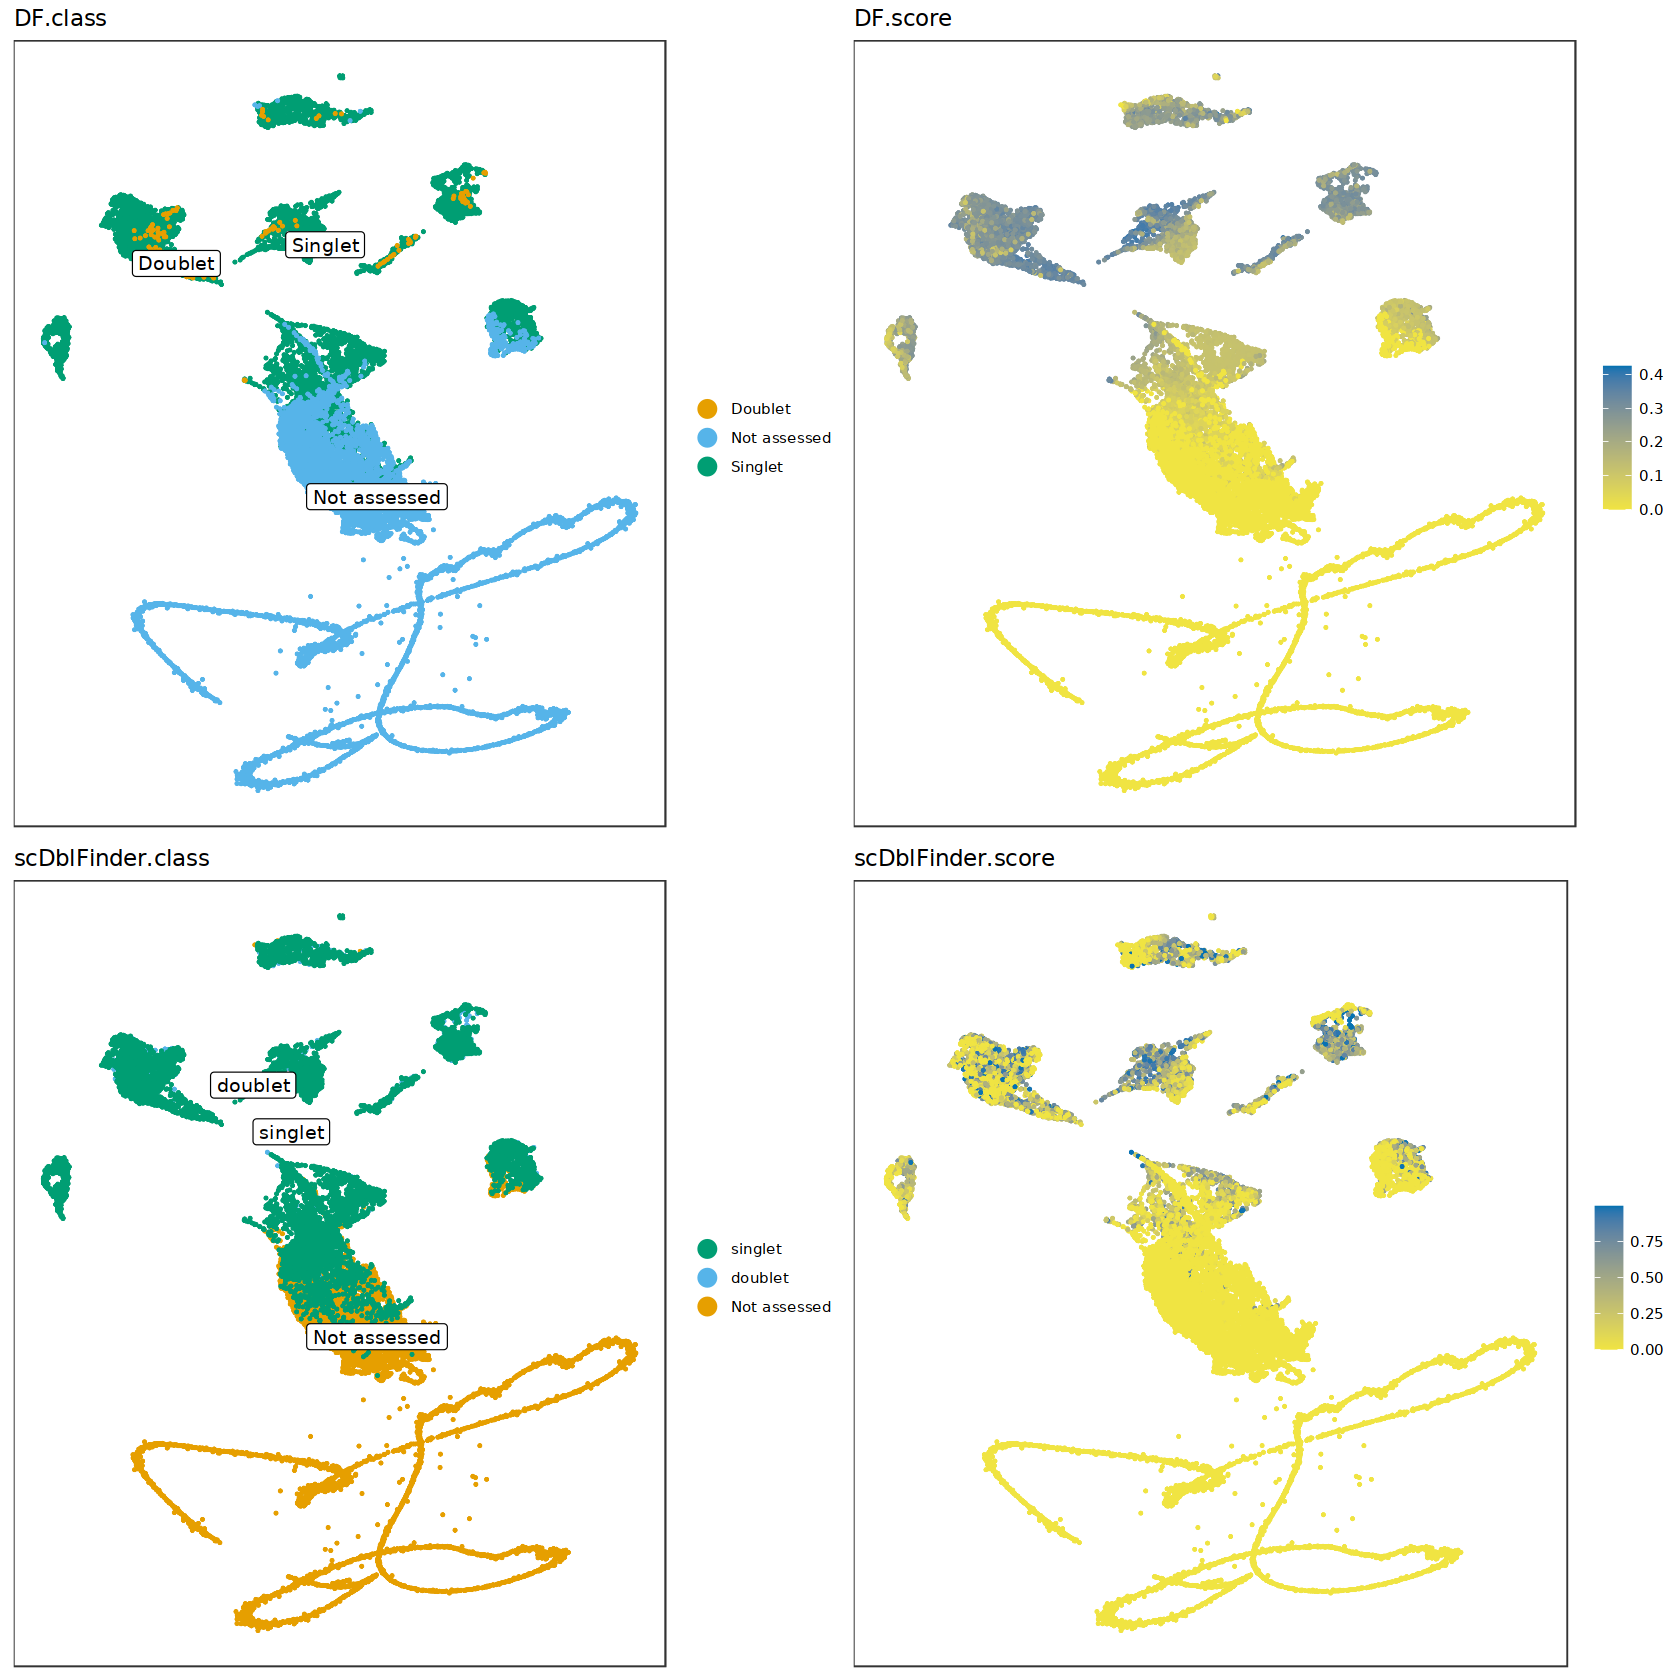

In [25]:
options(repr.plot.height = 14, repr.plot.width = 14)
p1 <- dittoDimPlot(DeSisto2023, 
                   order = c("decreasing"),
             reduction.use = "umap", var = "DF.class", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 
p2 <- dittoDimPlot(DeSisto2023,
             reduction.use = "umap", var = "DF.score", 
             do.raster = TRUE) + NoAxes() 
p3 <- dittoDimPlot(DeSisto2023,
                   order = c("decreasing"),
                   color.panel = rev(dittoColors()[1:3]),
             reduction.use = "umap", var = "scDblFinder.class", 
             do.label = T, labels.size = 4, 
             do.raster = TRUE) + NoAxes() 
p4 <- dittoDimPlot(DeSisto2023,
             reduction.use = "umap", var = "scDblFinder.score", 
             do.raster = TRUE) + NoAxes() 
cowplot::plot_grid(p1, p2, p3, p4,
                  label = 'AUTO',
                  ncol=2, nrow=2)

Warning message:
“Some of the plotted features are from meta.data slot.
• Please check that `na_cutoff` param is being set appropriately
  for those features.”


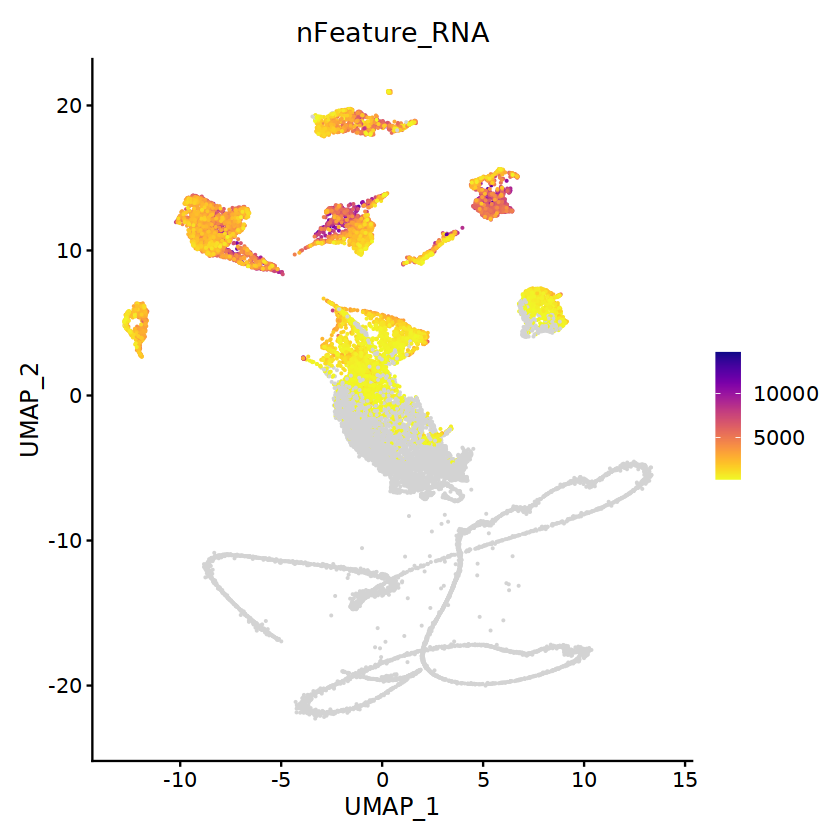

In [26]:
options(repr.plot.height = 7, repr.plot.width = 7)
FeaturePlot_scCustom(seurat_object = DeSisto2023, order = F,
                     features = "nFeature_RNA", na_cutoff = 200)

In [27]:
table(DeSisto2023$DF.class)
table(DeSisto2023$scDblFinder.class)


     Doublet Not assessed      Singlet 
         179         9984         9477 


     singlet      doublet Not assessed 
        9021          635         9984 

In [28]:
DeSisto2023 <- Add_Mito_Ribo_Seurat(seurat_object = DeSisto2023, species = "Human")
DeSisto2023 <- Add_Cell_Complexity_Seurat(seurat_object = DeSisto2023)

Warning message:
“Removed 3 rows containing non-finite values (`stat_ydensity()`).”


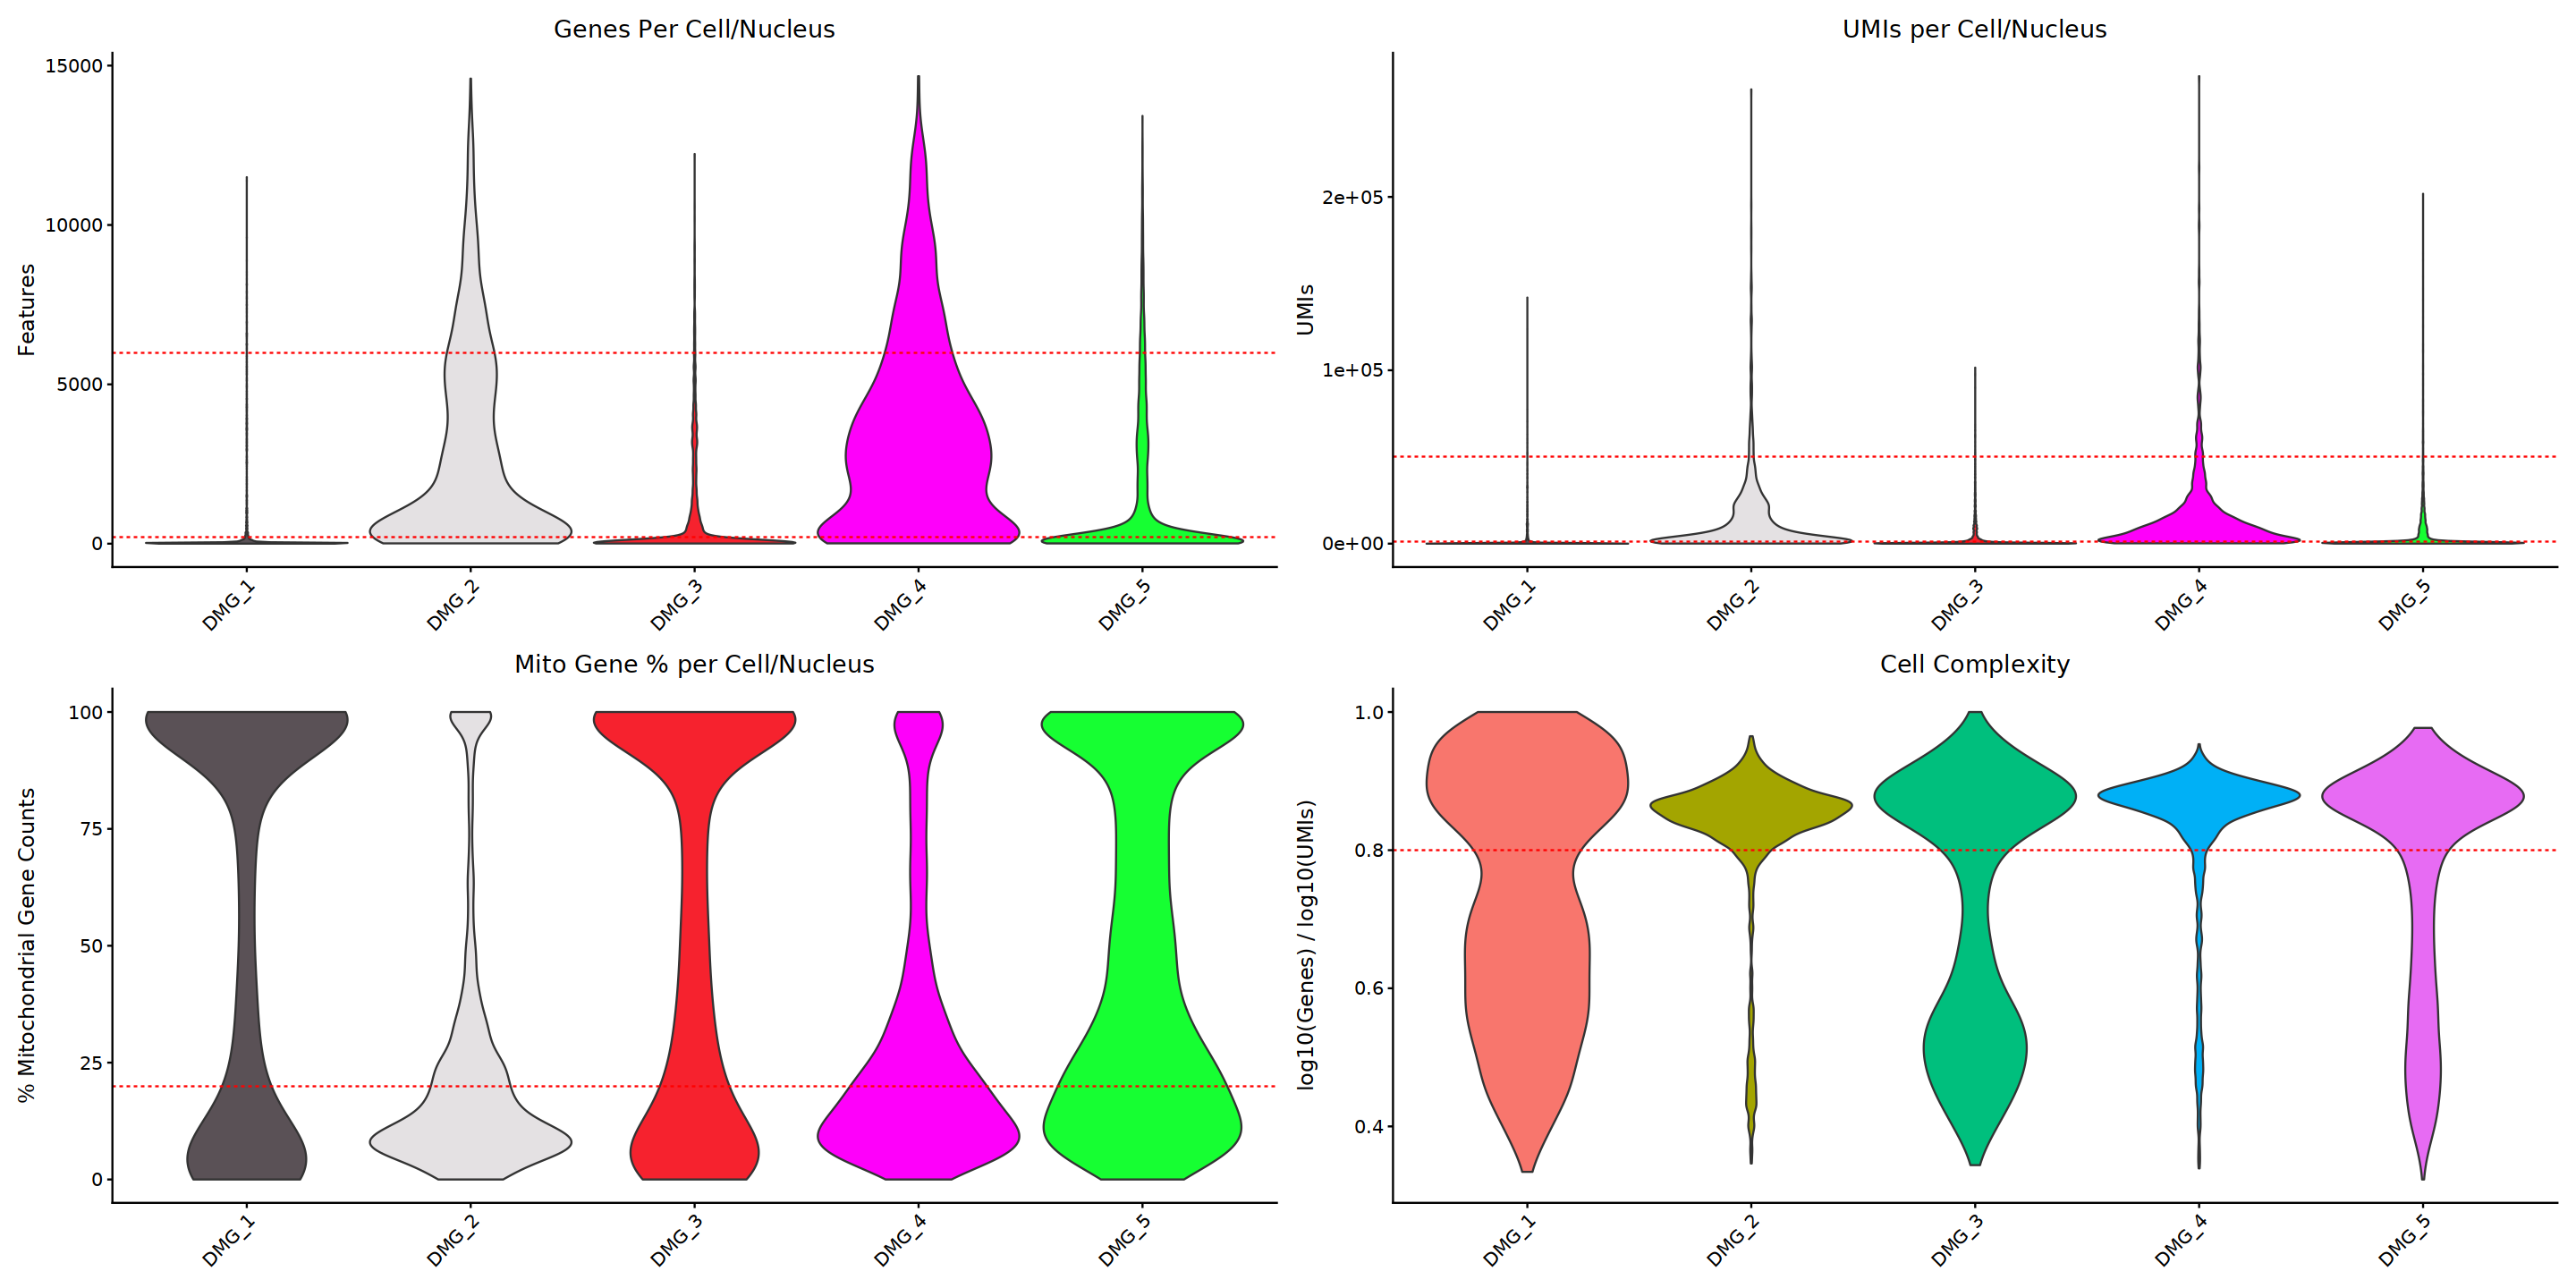

In [29]:
options(repr.plot.height = 12, repr.plot.width = 24)

# All functions contain
p1 <- QC_Plots_Genes(seurat_object = DeSisto2023, group.by = 'ID', pt.size = 0,
                     low_cutoff = 200, high_cutoff = 6000)
p2 <- QC_Plots_UMIs(seurat_object = DeSisto2023, group.by = 'ID', pt.size = 0,
                    low_cutoff = 1000, high_cutoff = 50000)
p3 <- QC_Plots_Mito(seurat_object = DeSisto2023, group.by = 'ID', pt.size = 0,
                    high_cutoff = 20)
p4 <- QC_Plots_Complexity(seurat_object = DeSisto2023, group.by = 'ID', pt.size = 0,
                          high_cutoff = 0.8)
wrap_plots(p1, p2, p3, p4, ncol = 2, nrow =2)

Scale for y is already present.
Adding another scale for y, which will replace the existing
scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing
scale.


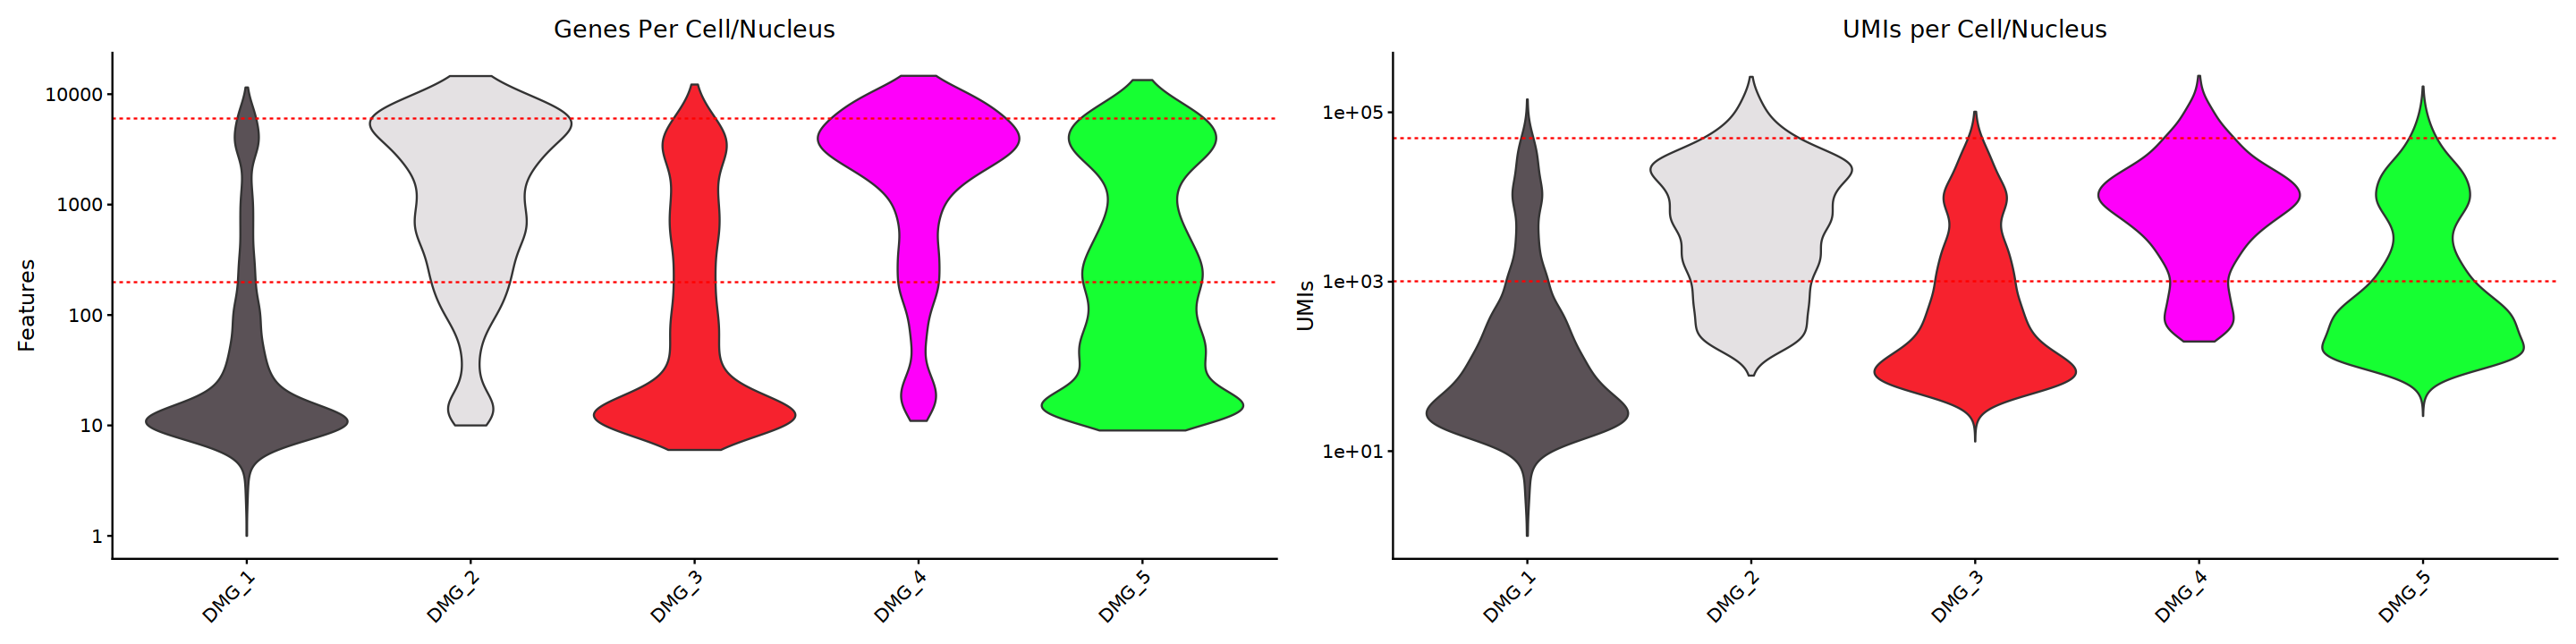

In [30]:
options(repr.plot.height = 6, repr.plot.width = 24)

# All functions contain
p1 <- QC_Plots_Genes(seurat_object = DeSisto2023, group.by = 'ID', low_cutoff = 200, high_cutoff = 6000,
                    y_axis_log = TRUE, pt.size = 0)
p2 <- QC_Plots_UMIs(seurat_object = DeSisto2023, group.by = 'ID', low_cutoff = 1000, high_cutoff = 50000,
                   y_axis_log = TRUE, pt.size = 0)
wrap_plots(p1, p2, ncol = 2)

##### scDblFinder results

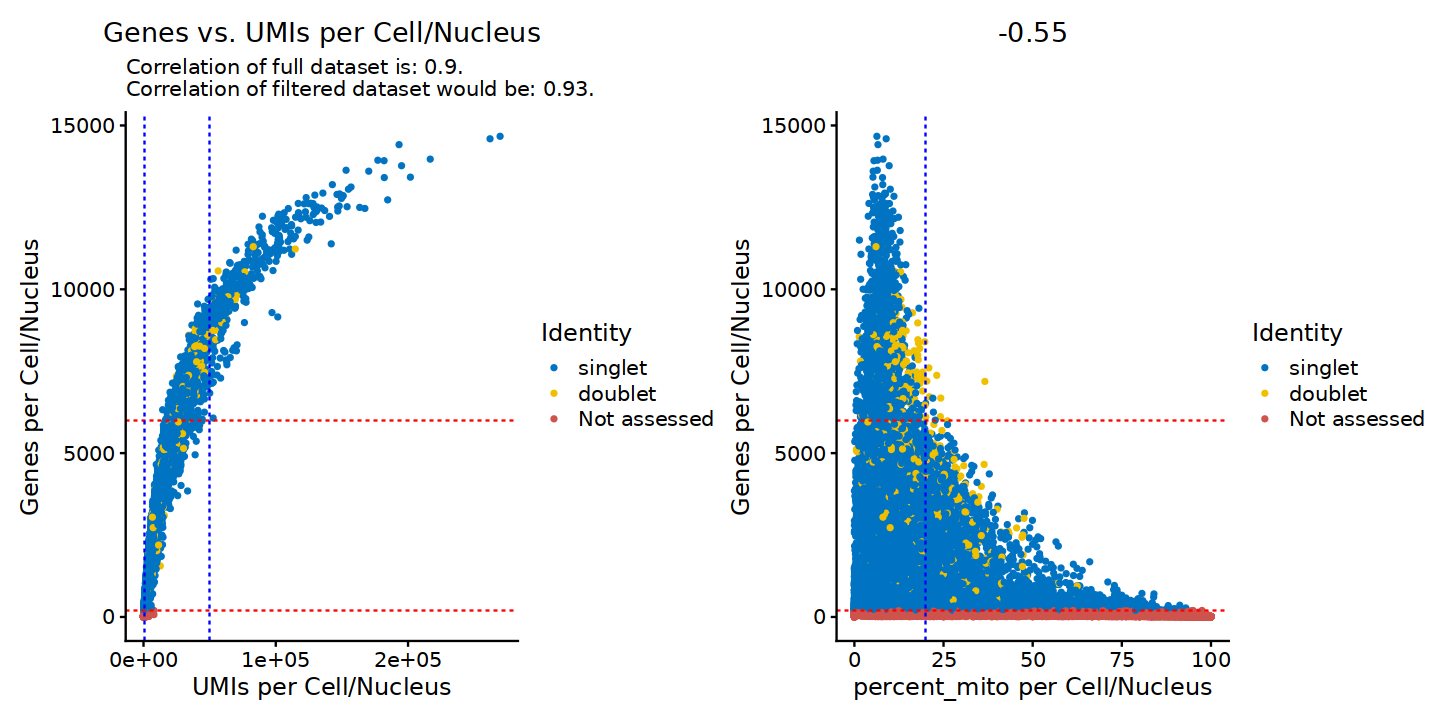

In [31]:
options(repr.plot.height = 6, repr.plot.width = 12)
# All functions contain
p1 <- QC_Plot_UMIvsGene(seurat_object = DeSisto2023, low_cutoff_gene = 200, high_cutoff_gene = 6000, low_cutoff_UMI = 1000,
    high_cutoff_UMI = 50000, group.by = 'scDblFinder.class')
p2<- QC_Plot_GenevsFeature(seurat_object = DeSisto2023, feature1 = "percent_mito", low_cutoff_gene = 200,
    high_cutoff_gene = 6000, high_cutoff_feature = 20, group.by = 'scDblFinder.class')
wrap_plots(p1, p2, ncol = 2)

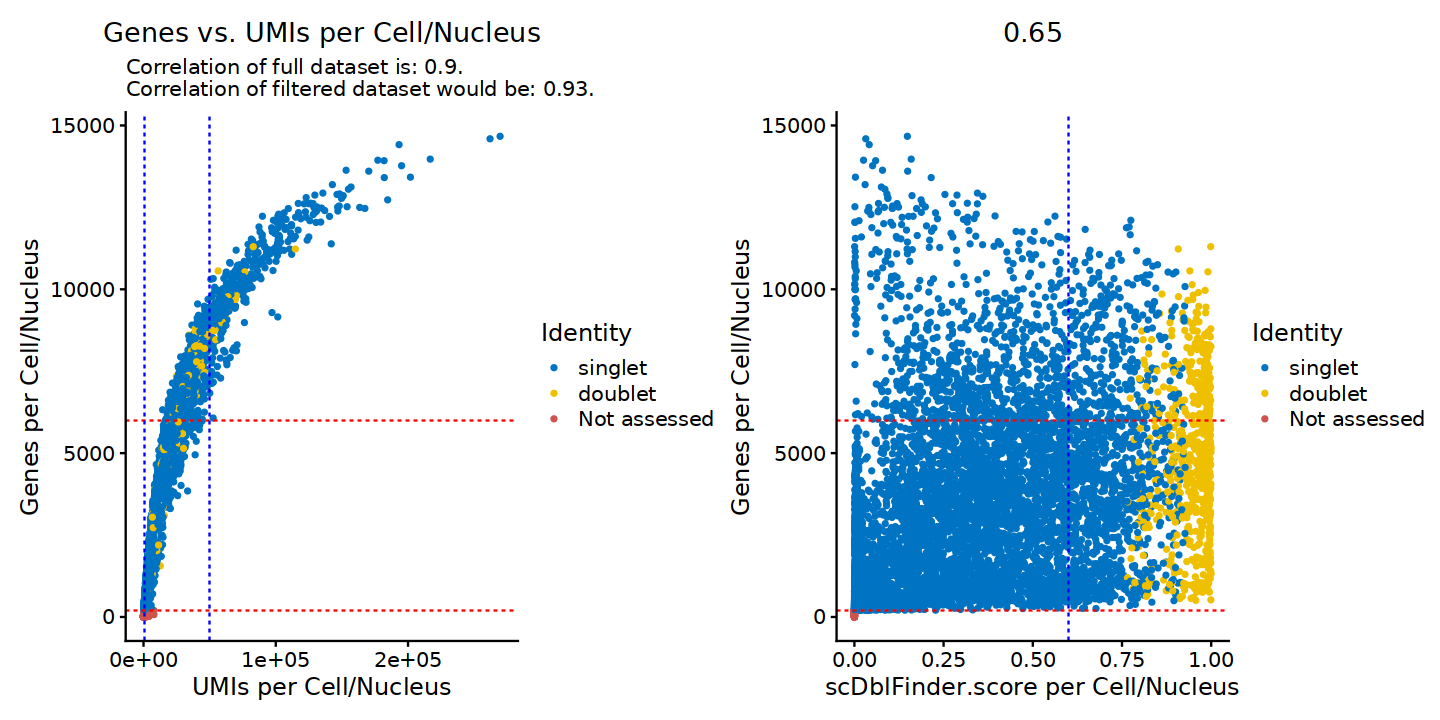

In [32]:
options(repr.plot.height = 6, repr.plot.width = 12)
# All functions contain
p1 <- QC_Plot_UMIvsGene(seurat_object = DeSisto2023, low_cutoff_gene = 200, high_cutoff_gene = 6000, low_cutoff_UMI = 1000,
    high_cutoff_UMI = 50000, group.by = 'scDblFinder.class')
p2<- QC_Plot_GenevsFeature(seurat_object = DeSisto2023, feature1 = "scDblFinder.score", low_cutoff_gene = 200,
    high_cutoff_gene = 6000, high_cutoff_feature = 0.6, group.by = 'scDblFinder.class')
wrap_plots(p1, p2, ncol = 2)

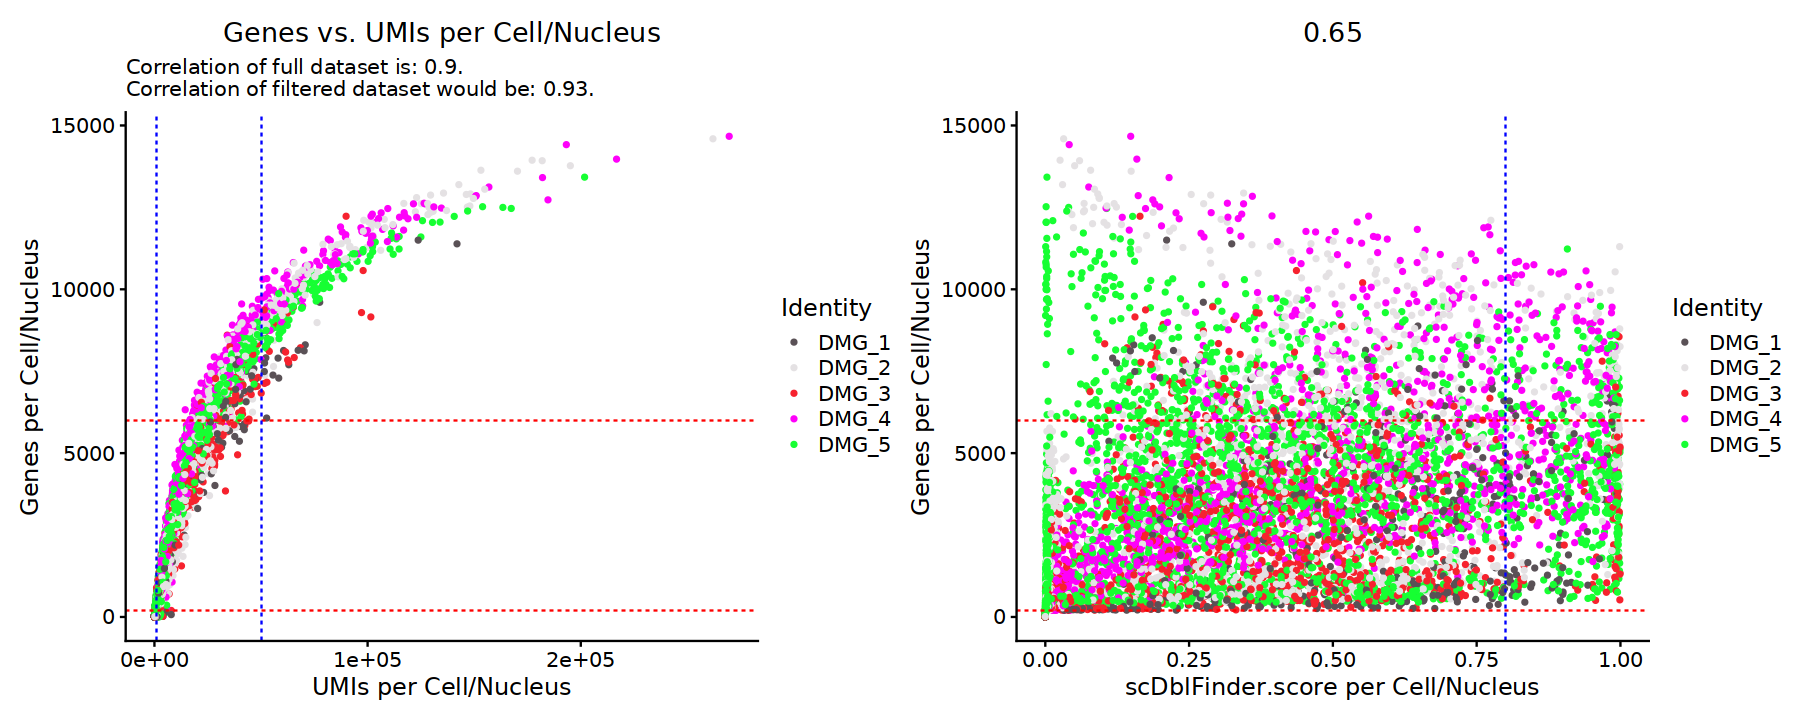

In [33]:
options(repr.plot.height = 6, repr.plot.width = 15)
# All functions contain
p1 <- QC_Plot_UMIvsGene(seurat_object = DeSisto2023, low_cutoff_gene = 200, high_cutoff_gene = 6000, low_cutoff_UMI = 1000,
    high_cutoff_UMI = 50000, group.by = 'ID')
p2<- QC_Plot_GenevsFeature(seurat_object = DeSisto2023, feature1 = "scDblFinder.score", low_cutoff_gene = 200,
    high_cutoff_gene = 6000, high_cutoff_feature = 0.8, group.by = 'ID')
wrap_plots(p1, p2, ncol = 2)

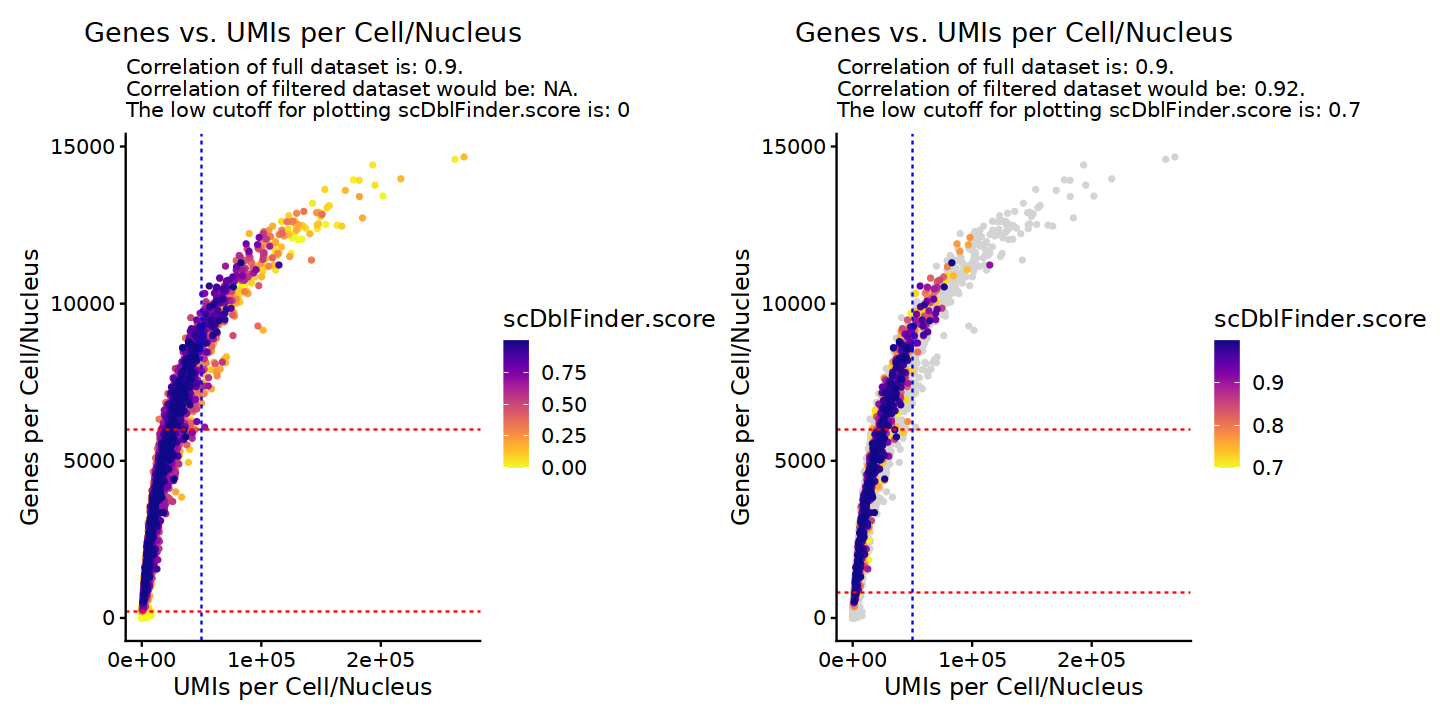

In [34]:
options(repr.plot.height = 6, repr.plot.width = 12)
p1 <- QC_Plot_UMIvsGene(seurat_object = DeSisto2023, meta_gradient_name = "scDblFinder.score", low_cutoff_gene = 200,
    high_cutoff_gene = 6000, high_cutoff_UMI = 50000)
p2 <- QC_Plot_UMIvsGene(seurat_object = DeSisto2023, meta_gradient_name = "scDblFinder.score", low_cutoff_gene = 800,
    high_cutoff_gene = 6000, high_cutoff_UMI = 50000, meta_gradient_low_cutoff = 0.7)
wrap_plots(p1, p2, ncol = 2)

##### DoubletFinder results

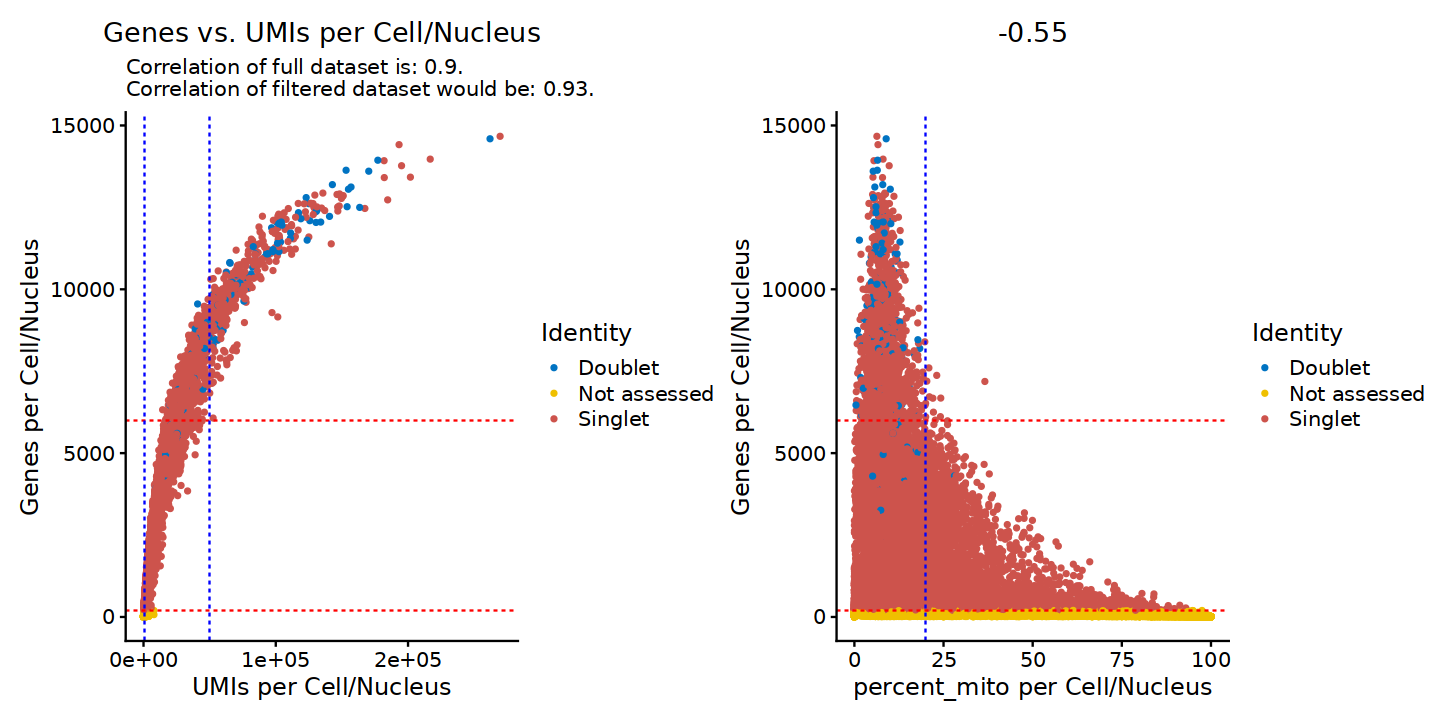

In [35]:
options(repr.plot.height = 6, repr.plot.width = 12)
# All functions contain
p1 <- QC_Plot_UMIvsGene(seurat_object = DeSisto2023, low_cutoff_gene = 200, high_cutoff_gene = 6000, low_cutoff_UMI = 1000,
    high_cutoff_UMI = 50000, group.by = 'DF.class')
p2 <- QC_Plot_GenevsFeature(seurat_object = DeSisto2023, feature1 = "percent_mito", low_cutoff_gene = 200,
    high_cutoff_gene = 6000, high_cutoff_feature = 20, group.by = 'DF.class')
wrap_plots(p1, p2, ncol = 2)

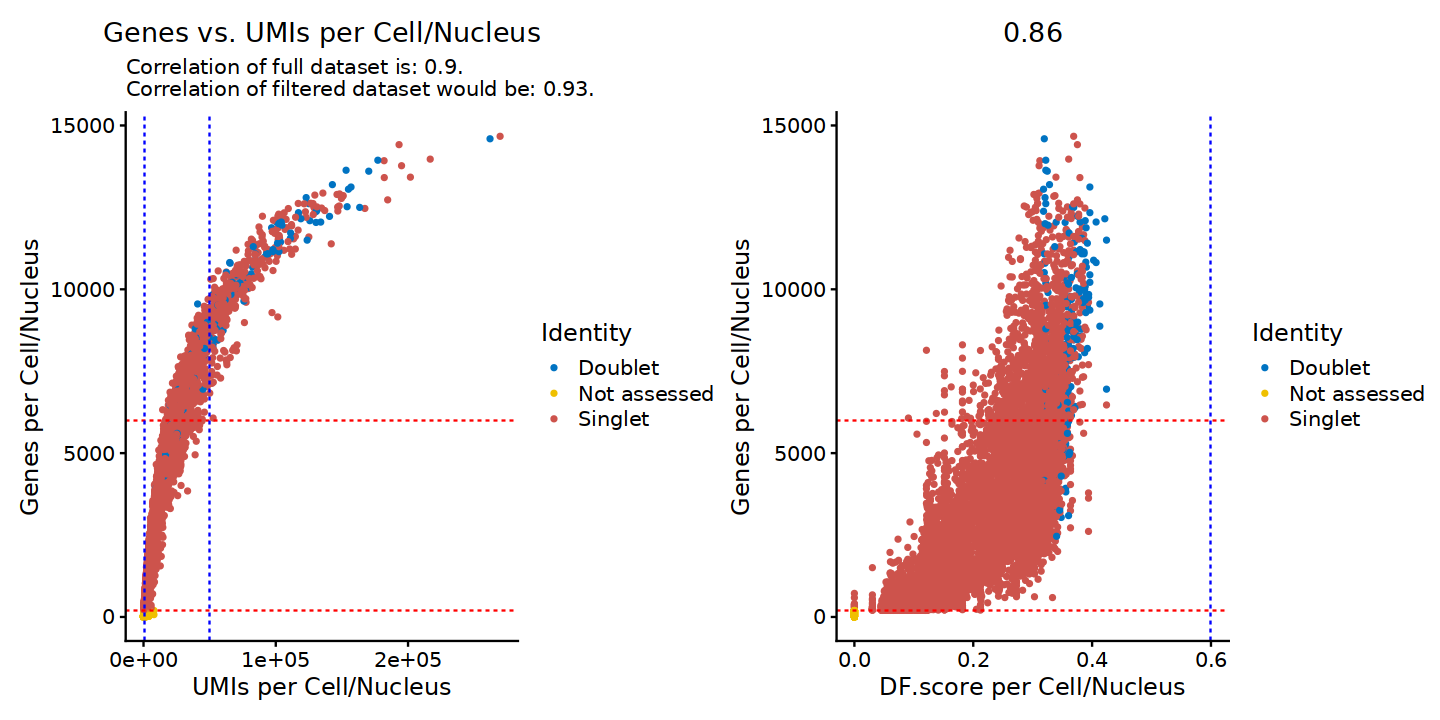

In [36]:
options(repr.plot.height = 6, repr.plot.width = 12)
# All functions contain
p1 <- QC_Plot_UMIvsGene(seurat_object = DeSisto2023, low_cutoff_gene = 200, high_cutoff_gene = 6000, low_cutoff_UMI = 1000,
    high_cutoff_UMI = 50000, group.by = 'DF.class')
p2<- QC_Plot_GenevsFeature(seurat_object = DeSisto2023, feature1 = "DF.score", low_cutoff_gene = 200,
    high_cutoff_gene = 6000, high_cutoff_feature = 0.6, group.by = 'DF.class')
wrap_plots(p1, p2, ncol = 2)

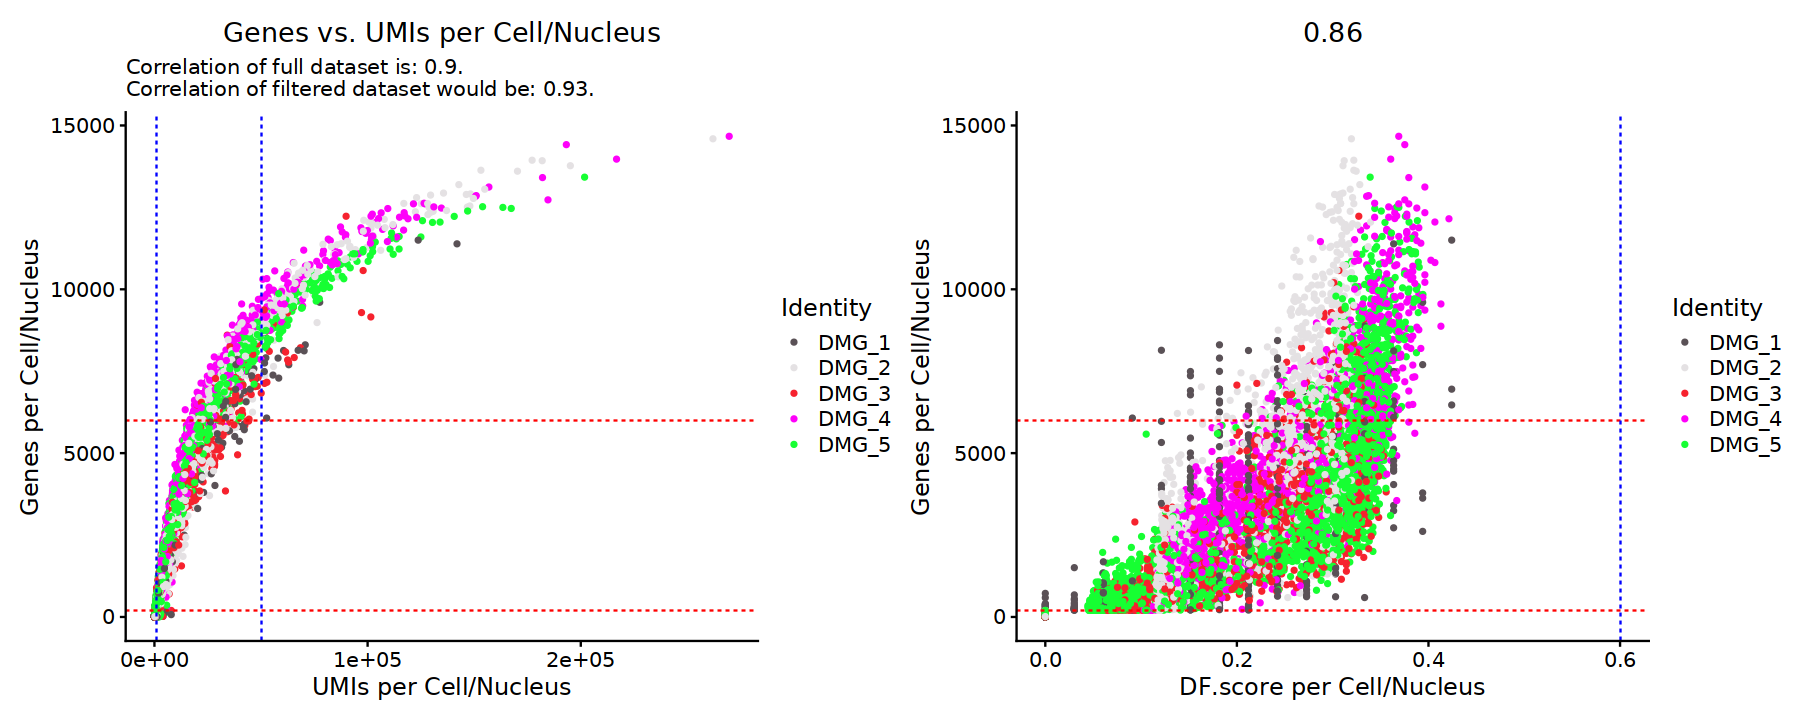

In [37]:
options(repr.plot.height = 6, repr.plot.width = 15)
# All functions contain
p1 <- QC_Plot_UMIvsGene(seurat_object = DeSisto2023, low_cutoff_gene = 200, high_cutoff_gene = 6000, low_cutoff_UMI = 1000,
    high_cutoff_UMI = 50000, group.by = 'ID')
p2<- QC_Plot_GenevsFeature(seurat_object = DeSisto2023, feature1 = "DF.score", low_cutoff_gene = 200,
    high_cutoff_gene = 6000, high_cutoff_feature = 0.6, group.by = 'ID')
wrap_plots(p1, p2, ncol = 2)

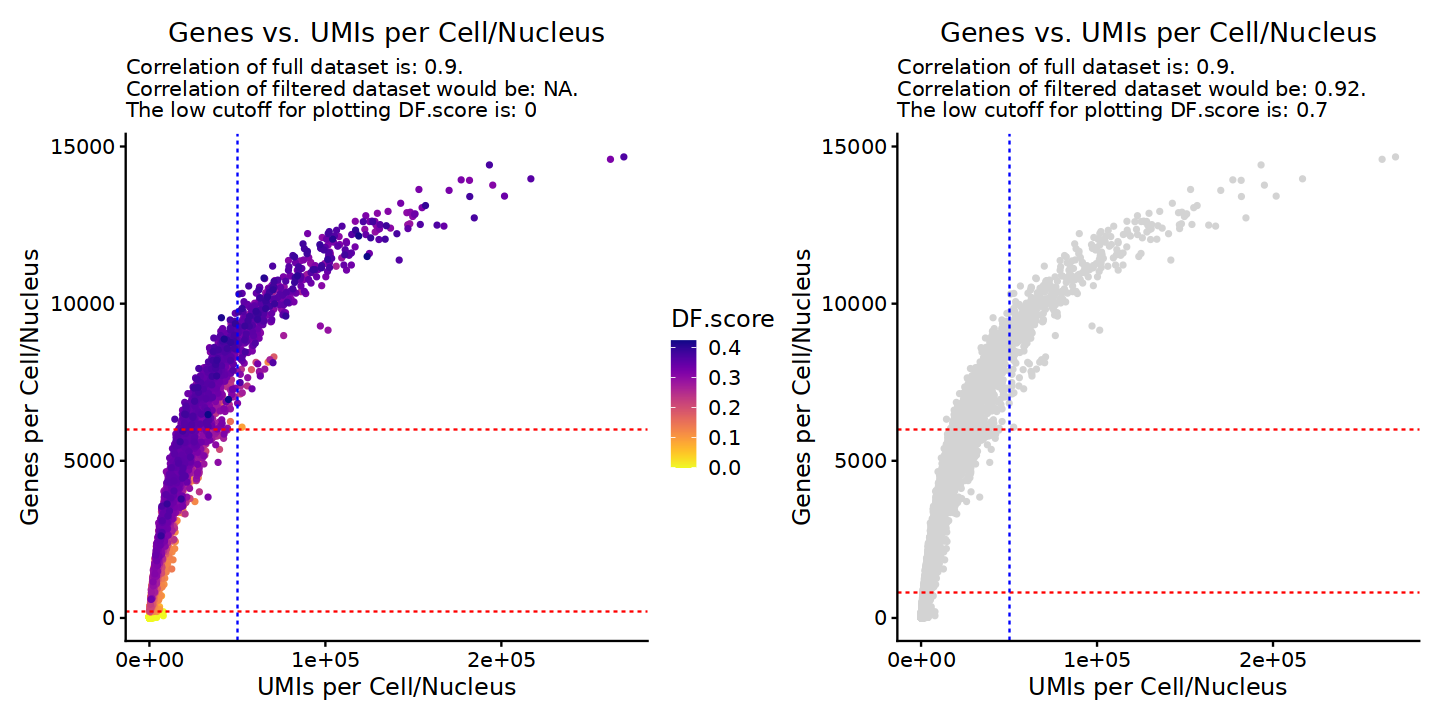

In [38]:
options(repr.plot.height = 6, repr.plot.width = 12)
p1 <- QC_Plot_UMIvsGene(seurat_object = DeSisto2023, meta_gradient_name = "DF.score", low_cutoff_gene = 200,
    high_cutoff_gene = 6000, high_cutoff_UMI = 50000)
p2 <- QC_Plot_UMIvsGene(seurat_object = DeSisto2023, meta_gradient_name = "DF.score", low_cutoff_gene = 800,
    high_cutoff_gene = 6000, high_cutoff_UMI = 50000, meta_gradient_low_cutoff = 0.7)
wrap_plots(p1, p2, ncol = 2)

In [39]:
saveRDS(DeSisto2023, '../data/DeSisto2023_no_filtered_with_doublet_scores.rds')

#### Add `scDblFinder` using cluster mode

In [2]:
DeSisto2023 <- readRDS('../data/DeSisto2023_no_filtered_with_doublet_scores.rds')

In [3]:
low_quality <- subset(DeSisto2023, subset = nFeature_RNA <= 200)
high_quality <- subset(DeSisto2023, subset = nFeature_RNA > 200)
low_quality
high_quality

An object of class Seurat 
73202 features across 13626 samples within 2 assays 
Active assay: RNA (36601 features, 2000 variable features)
 1 other assay present: RAW
 2 dimensional reductions calculated: pca, umap

An object of class Seurat 
73202 features across 245837 samples within 2 assays 
Active assay: RNA (36601 features, 2000 variable features)
 1 other assay present: RAW
 2 dimensional reductions calculated: pca, umap

In [6]:
bp <- MulticoreParam(12, RNGseed=1234)
high_quality_sce <- scDblFinder(GetAssayData(high_quality, slot="counts"), 
                            samples=high_quality$SampleID, 
                            clusters=TRUE,
                            BPPARAM=bp)
high_quality$scDblFinder.clusters.score <- high_quality_sce$scDblFinder.score
high_quality$scDblFinder.clusters.class <- high_quality_sce$scDblFinder.class

Assuming the input to be a matrix of counts or expected counts.



In [8]:
low_quality$scDblFinder.clusters.class <- 'Not assessed'
low_quality$scDblFinder.clusters.score <- 0

In [9]:
doublet_meta <- rbind(FetchData(high_quality, c('scDblFinder.clusters.class', 
                                                'scDblFinder.clusters.score')),
                      FetchData(low_quality, c('scDblFinder.clusters.class', 
                                               'scDblFinder.clusters.score'))
                               )
doublet_meta

,scDblFinder.clusters.class,scDblFinder.clusters.score
,<fct>,<dbl>
BT042_PD_GGTCTGGAGCCTTCTC-1,singlet,0.84675878
BT042_PD_CCGTTCATCTATGTGG-1,singlet,0.65521944
BT042_PD_CTACCTGGTATGAAAC-1,singlet,0.37785703
BT042_PD_TACTTACAGGAGAGGC-1,doublet,0.99489105
BT042_PD_TTGCATTTCCTGTAGA-1,singlet,0.07962210
BT042_PD_GTGCTGGGTAACGCGA-1,singlet,0.14099813
BT042_PD_TCCGATCTCGACACCG-1,singlet,0.85857892
BT042_PD_GGGTAGACACCAAATC-1,doublet,0.99475139
BT042_PD_TAGACTGCAGTCGCAC-1,singlet,0.85991418


In [10]:
DeSisto2023 <- AddMetaData(DeSisto2023, doublet_meta)
DeSisto2023@meta.data

,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,DF.class,DF.score,scDblFinder.class,scDblFinder.score,ID,SampleID,Data,percent_mito,percent_ribo,percent_mito_ribo,log10GenesPerUMI,nFeature_Diff,nCount_Diff,Batch_for_correction,scDblFinder.clusters.class,scDblFinder.clusters.score
,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<fct>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<fct>,<dbl>
BT042_PD_GGTCTGGAGCCTTCTC-1,12121,4072,12184,4079,Doublet,0.23636364,singlet,0.31661707,T18-90532,BT042_PD,RNA_only,0.09075159,26.00445508,26.0952067,0.8839902,7,63,10Xv3.1_nuclei_rna,singlet,0.84675878
BT042_PD_CCGTTCATCTATGTGG-1,11704,3579,11772,3607,Singlet,0.10909091,singlet,0.66635233,T18-90532,BT042_PD,RNA_only,0.00000000,0.25632262,0.2563226,0.8735176,28,68,10Xv3.1_nuclei_rna,singlet,0.65521944
BT042_PD_CTACCTGGTATGAAAC-1,10186,4021,10298,4052,Singlet,0.12727273,singlet,0.66635233,T18-90532,BT042_PD,RNA_only,0.10799136,1.50206165,1.6100530,0.8992841,31,112,10Xv3.1_nuclei_rna,singlet,0.37785703
BT042_PD_TACTTACAGGAGAGGC-1,9416,3261,9587,3282,Singlet,0.09090909,doublet,0.99749988,T18-90532,BT042_PD,RNA_only,1.65675446,0.46728972,2.1240442,0.8841140,21,171,10Xv3.1_nuclei_rna,doublet,0.99489105
BT042_PD_TTGCATTTCCTGTAGA-1,8378,3249,8439,3276,Singlet,0.10909091,singlet,0.42149284,T18-90532,BT042_PD,RNA_only,0.00000000,0.90713774,0.9071377,0.8951374,27,61,10Xv3.1_nuclei_rna,singlet,0.07962210
BT042_PD_GTGCTGGGTAACGCGA-1,7870,3445,8029,3477,Singlet,0.07272727,doublet,0.98795068,T18-90532,BT042_PD,RNA_only,0.22871665,2.94790343,3.1766201,0.9079087,32,159,10Xv3.1_nuclei_rna,singlet,0.14099813
BT042_PD_TCCGATCTCGACACCG-1,7339,2387,7577,2426,Singlet,0.09090909,doublet,0.90838033,T18-90532,BT042_PD,RNA_only,2.49352773,0.12263251,2.6161602,0.8738152,39,238,10Xv3.1_nuclei_rna,singlet,0.85857892
BT042_PD_GGGTAGACACCAAATC-1,6782,2734,6893,2749,Singlet,0.14545455,doublet,0.99750715,T18-90532,BT042_PD,RNA_only,0.17693896,3.02270717,3.1996461,0.8970184,15,111,10Xv3.1_nuclei_rna,doublet,0.99475139
BT042_PD_TAGACTGCAGTCGCAC-1,6403,2378,6459,2398,Singlet,0.16363636,doublet,0.92105341,T18-90532,BT042_PD,RNA_only,0.00000000,1.29626737,1.2962674,0.8869868,20,56,10Xv3.1_nuclei_rna,singlet,0.85991418


In [11]:
# change spelling of scDblFinder.class
DeSisto2023$scDblFinder.class <- recode(DeSisto2023$scDblFinder.class,
                                     `singlet` = 'Singlet',
                                     `doublet` = 'Doublet')
DeSisto2023$scDblFinder.clusters.class <- recode(DeSisto2023$scDblFinder.clusters.class,
                                     `singlet` = 'Singlet',
                                     `doublet` = 'Doublet')

In [12]:
DeSisto2023$DF.class <- factor(DeSisto2023$DF.class, 
                            levels = c('Singlet', 'Doublet', 'Not assessed'))
DeSisto2023$scDblFinder.class <- factor(DeSisto2023$scDblFinder.class, 
                                     levels = c('Singlet', 'Doublet', 'Not assessed'))
DeSisto2023$scDblFinder.class.clusters <- factor(DeSisto2023$scDblFinder.clusters.class, 
                                     levels = c('Singlet', 'Doublet', 'Not assessed'))

In [13]:
table(DeSisto2023$scDblFinder.class)
table(DeSisto2023$scDblFinder.clusters.class)


     Singlet      Doublet Not assessed 
      223507        22330        13626 


     Singlet      Doublet Not assessed 
      225177        20660        13626 

In [14]:
table(DeSisto2023$scDblFinder.class, DeSisto2023$scDblFinder.clusters.class)

              
               Singlet Doublet Not assessed
  Singlet       219441    4066            0
  Doublet         5736   16594            0
  Not assessed       0       0        13626

In [15]:
saveRDS(DeSisto2023, '../data/DeSisto2023_no_filtered_with_doublet_scores.rds')